# Notebook 6 - Análise final dos modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import optuna
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.CRITICAL)

import funcoes_modelagem

C:\Users\Victor Dogo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pasta_dados = Path('dados')
arquivos_bases = sorted(pasta_dados.glob('3-*.pkl'))

bases = {}
for caminho_base in arquivos_bases:
    nome_base = caminho_base.stem.removeprefix('3-')
    bases[nome_base] = pd.read_pickle(caminho_base)
    globals()[nome_base] = bases[nome_base]

print('Bases carregadas:')
for nome_base, base in bases.items():
    print(f'{nome_base}: {base.shape[0]} linhas x {base.shape[1]} colunas')

base_analise = pd.concat([bases['base_teste'], bases['base_oot']]).reset_index(drop=True)
base_analise.shape

Bases carregadas:
base_oot: 131 linhas x 31 colunas
base_teste: 188 linhas x 32 colunas
base_treino: 439 linhas x 32 colunas


(319, 32)

In [3]:
target = 'regularizou_30d'
datas = 'safra'

In [4]:
import pickle
import joblib
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp


def localizar_modelo(nome):
    candidatos = [
        caminho for caminho in Path('modelos').rglob('*')
        if caminho.is_file()
        and nome.lower() in caminho.stem.lower()
        and caminho.suffix.lower() in {'.pkl', '.pickle', '.joblib'}
    ]

    if not candidatos:
        raise FileNotFoundError(f'Modelo não encontrado: {nome}')

    return candidatos[0]


def carregar_modelo(caminho):
    try:
        return joblib.load(caminho)
    except Exception:
        with open(caminho, 'rb') as arquivo:
            return pickle.load(arquivo)


def obter_modelo_segmentado(modelo, linha):
    if hasattr(modelo, 'models_'):
        modelo = modelo.models_

    if not isinstance(modelo, dict):
        return modelo

    chaves = [
        linha.get('regiao'),
        linha.get('flag_safra'),
        linha.get('safra'),
        linha.get('setor'),
        linha.get('porte'),
        'default',
        'modelo',
    ]

    for chave in chaves:
        if chave in modelo:
            return modelo[chave]

    raise KeyError(f'Não foi encontrado modelo para a linha: {linha}')


def obter_nomes_features(modelo, dados):
    if hasattr(modelo, 'feature_name'):
        nomes = modelo.feature_name()
    else:
        nomes = getattr(modelo, 'feature_names_in_', None)

    if nomes is None:
        return list(dados.columns)

    nomes = list(nomes)
    nomes_ausentes = sorted(set(nomes) - set(dados.columns))
    if nomes_ausentes:
        raise KeyError(f'Features ausentes na base de análise: {nomes_ausentes}')

    return nomes


def preparar_features(modelo, dados):
    nomes = obter_nomes_features(modelo, dados)
    features_modelo = dados[nomes].copy()

    for coluna in features_modelo.select_dtypes(include=['category', 'object']).columns:
        if isinstance(features_modelo[coluna].dtype, pd.CategoricalDtype):
            features_modelo[coluna] = features_modelo[coluna].cat.codes
        else:
            features_modelo[coluna] = pd.factorize(features_modelo[coluna])[0]

    return np.ascontiguousarray(features_modelo.to_numpy(dtype=np.float32))


def prever(modelo, dados):
    X = preparar_features(modelo, dados)

    if hasattr(modelo, 'predict_proba'):
        predicao = modelo.predict_proba(X)
        return predicao[:, 1] if predicao.ndim > 1 else predicao

    if hasattr(modelo, 'predict'):
        return np.asarray(modelo.predict(X)).ravel()

    raise TypeError(f'Objeto de modelo sem método de previsão: {type(modelo)}')


def calcular_metricas(dados, score):
    y = dados[target].astype(int)
    score = pd.Series(score, index=dados.index)

    if y.nunique() < 2:
        return pd.Series({'AUC': np.nan, 'KS': np.nan, 'n': len(dados)})

    ks = ks_2samp(
        score[y == 1].dropna(),
        score[y == 0].dropna()
    ).statistic

    return pd.Series({
        'AUC': roc_auc_score(y, score),
        'KS': ks,
        'n': len(dados)
    })


caminho_unico = localizar_modelo('modelo_unico')
caminho_segmentado = localizar_modelo('modelos_segmentados')

modelo_unico = carregar_modelo(caminho_unico)
modelos_segmentados = carregar_modelo(caminho_segmentado)

dados = base_analise.copy()
X = dados.drop(columns=[target], errors='ignore')

dados['score_modelo_unico'] = prever(modelo_unico, X)

dados['score_modelos_segmentados'] = [
    prever(
        obter_modelo_segmentado(modelos_segmentados, linha),
        X.loc[[indice]]
    )[0]
    for indice, linha in dados.iterrows()
]

dados['score_baseline'] = dados['score_regularizacao_legado']

modelos_scores = {
    'baseline_legado': 'score_baseline',
    'modelo_unico': 'score_modelo_unico',
    'modelos_segmentados': 'score_modelos_segmentados',
}


def avaliar_por_grupo(coluna):
    resultados = []

    for grupo, grupo_dados in dados.groupby(coluna, dropna=False):
        for nome_modelo, coluna_score in modelos_scores.items():
            metricas = calcular_metricas(
                grupo_dados,
                grupo_dados[coluna_score]
            )

            resultados.append({
                coluna: grupo,
                'modelo': nome_modelo,
                **metricas.to_dict()
            })

    return pd.DataFrame(resultados)


resultados_flag_safra = avaliar_por_grupo('flag_safra')
resultados_safra = avaliar_por_grupo('safra')

print('Resultados por flag_safra:')
display(pd.pivot(resultados_flag_safra, index='flag_safra', columns='modelo', values=['KS']))

print('Resultados por safra:')
display(pd.pivot(resultados_safra, index='safra', columns='modelo', values=['KS']))

Resultados por flag_safra:


KS                                 
modelo     baseline_legado modelo_unico modelos_segmentados
flag_safra                                                 
DES               0.371337     0.343407            0.326007
OOT               0.311972     0.248122            0.353052

Resultados por safra:


KS                                 
modelo  baseline_legado modelo_unico modelos_segmentados
safra                                                   
2026-01        0.476190     0.357143            0.309524
2026-02        0.423529     0.550000            0.497059
2026-03        0.548485     0.418182            0.396970
2026-04        0.576190     0.433333            0.409524
2026-05        0.486928     0.477124            0.431373
2026-06        0.311972     0.248122            0.353052

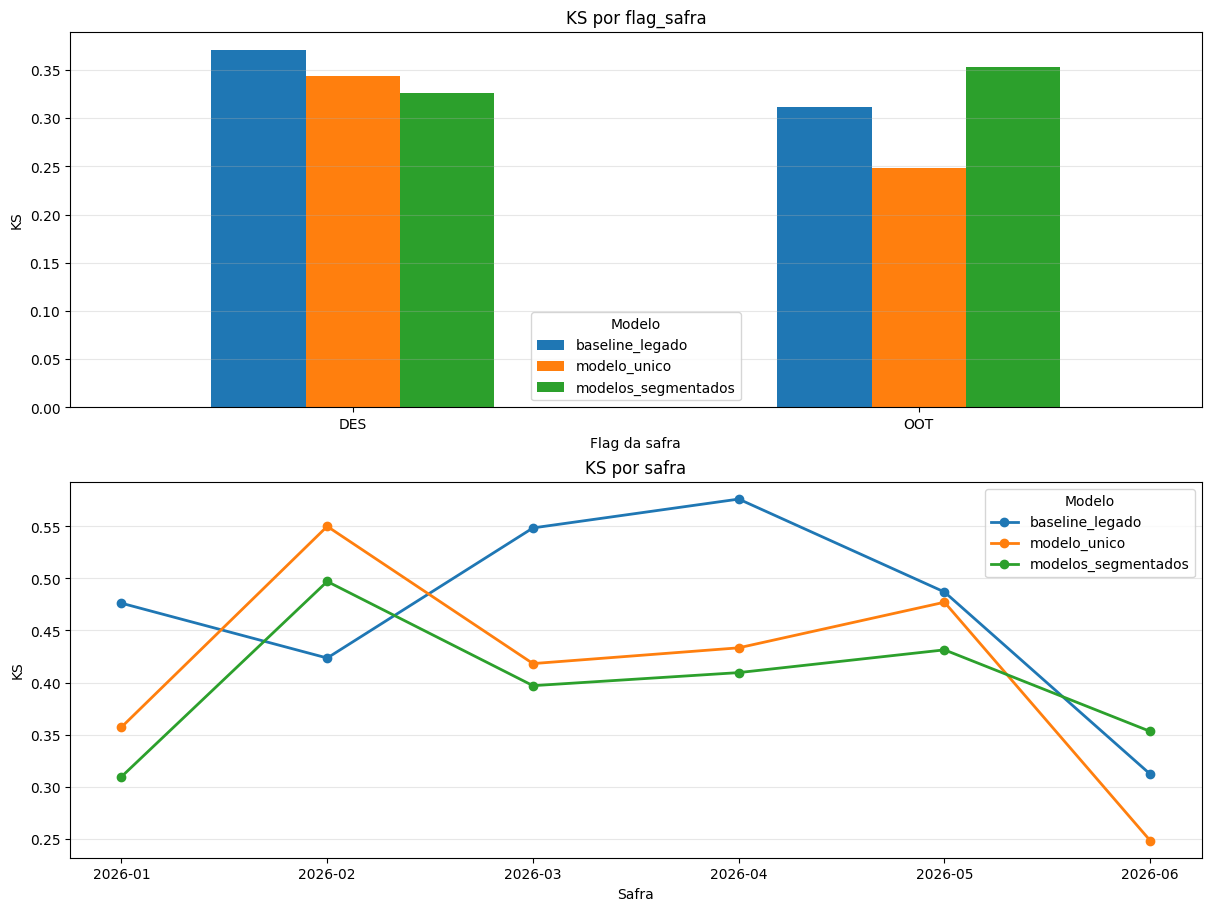

In [5]:
metrica = 'KS'

fig, (ax_barra, ax_linha) = plt.subplots(
    2, 1,
    figsize=(12, 9),
    constrained_layout=True
)

# Gráfico de barras: resultados por flag_safra
tabela_flag = resultados_flag_safra.pivot(
    index='flag_safra',
    columns='modelo',
    values=metrica
)

tabela_flag.plot(
    kind='bar',
    ax=ax_barra,
    rot=0
)

ax_barra.set_title(f'{metrica} por flag_safra')
ax_barra.set_xlabel('Flag da safra')
ax_barra.set_ylabel(metrica)
ax_barra.legend(title='Modelo')
ax_barra.grid(axis='y', alpha=0.3)

# Gráfico de linhas: resultados por safra
tabela_safra = resultados_safra.pivot(
    index='safra',
    columns='modelo',
    values=metrica
)

tabela_safra.plot(
    kind='line',
    marker='o',
    linewidth=2,
    ax=ax_linha
)

ax_linha.set_title(f'{metrica} por safra')
ax_linha.set_xlabel('Safra')
ax_linha.set_ylabel(metrica)
ax_linha.legend(title='Modelo')
ax_linha.grid(axis='y', alpha=0.3)

plt.show()

Resumo das variáveis por classe da resposta:


dias_atraso                      faturamento_mensal_estimado  \
                      count   mean median    std                       count   
regularizou_30d                                                                
0                       155  50.22   46.0  28.20                         155   
1                       164  32.61   30.0  18.94                         164   

                                                 
                      mean    median        std  
regularizou_30d                                  
0                248043.93  79627.47  467993.87  
1                199416.43  64623.92  391364.86


Taxa de regularização por faixa de dias_atraso:


,dias_atraso_faixa,quantidade,taxa_regularizacao,media_resposta
0,"(0.999, 17.0]",69,63.77,0.637681
1,"(17.0, 31.0]",63,66.67,0.666667
2,"(31.0, 43.0]",60,60.00,0.600000
3,"(43.0, 62.0]",65,43.08,0.430769
4,"(62.0, 113.0]",62,22.58,0.225806


Correlação de dias_atraso com regularizou_30d: -0.3466

Taxa de regularização por faixa de faturamento_mensal_estimado:


,faturamento_mensal_estimado_faixa,quantidade,taxa_regularizacao,media_resposta
0,"(8799.889, 31995.602]",64,56.25,0.562500
1,"(31995.602, 58039.95]",64,59.38,0.593750
2,"(58039.95, 96631.75]",63,52.38,0.523810
3,"(96631.75, 236969.344]",64,45.31,0.453125
4,"(236969.344, 2921977.3]",64,43.75,0.437500


Correlação de faturamento_mensal_estimado com regularizou_30d: -0.0566


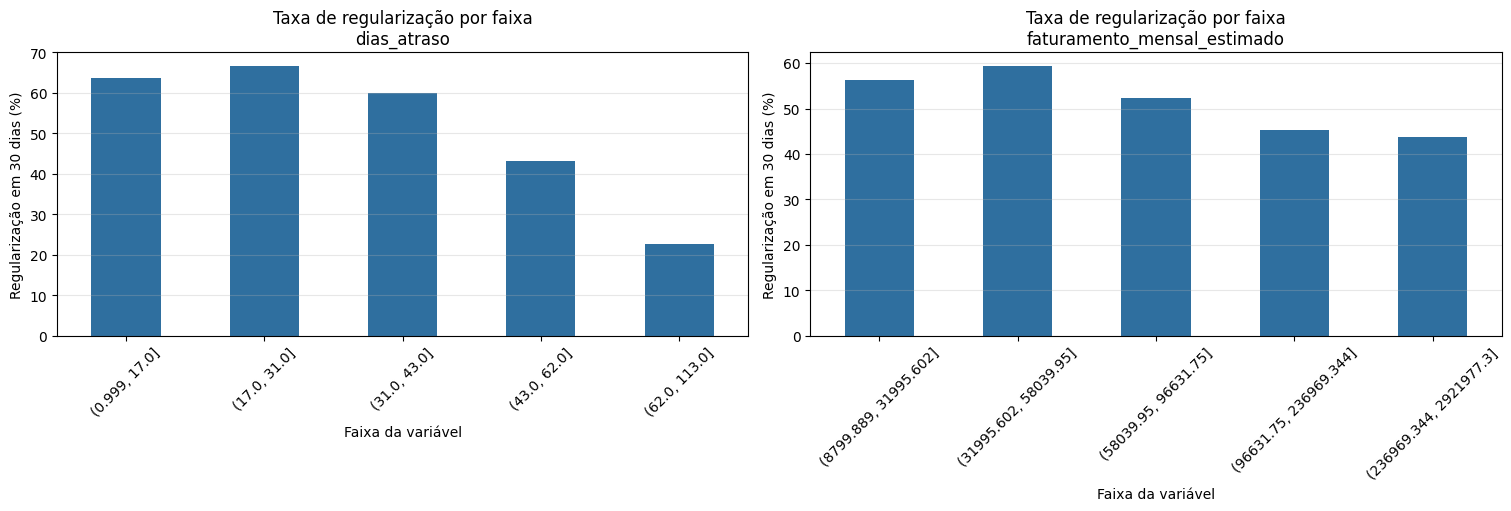

In [6]:
variaveis_analisadas = [
    'dias_atraso',
    'faturamento_mensal_estimado',
]

dados_variaveis = base_analise[variaveis_analisadas + [target]].copy()
dados_variaveis[target] = dados_variaveis[target].astype(int)

resumo_por_resposta = (
    dados_variaveis
    .groupby(target)[variaveis_analisadas]
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

print('Resumo das variáveis por classe da resposta:')
display(resumo_por_resposta)

for variavel in variaveis_analisadas:
    dados_variaveis[f'{variavel}_faixa'] = pd.qcut(
        dados_variaveis[variavel],
        q=5,
        duplicates='drop',
    )

    analise_faixas = (
        dados_variaveis
        .groupby(f'{variavel}_faixa', observed=False)
        .agg(
            quantidade=(target, 'size'),
            taxa_regularizacao=(target, 'mean'),
            media_resposta=(target, 'mean'),
        )
        .reset_index()
    )
    analise_faixas['taxa_regularizacao'] *= 100
    analise_faixas['taxa_regularizacao'] = analise_faixas['taxa_regularizacao'].round(2)

    print(f'\nTaxa de regularização por faixa de {variavel}:')
    display(analise_faixas)

    correlacao = dados_variaveis[[variavel, target]].corr().loc[variavel, target]
    print(f'Correlação de {variavel} com {target}: {correlacao:.4f}')

fig, eixos = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for eixo, variavel in zip(eixos, variaveis_analisadas):
    dados_grafico = dados_variaveis.copy()
    dados_grafico['faixa'] = pd.qcut(
        dados_grafico[variavel],
        q=5,
        duplicates='drop',
    )
    taxas = dados_grafico.groupby('faixa', observed=False)[target].mean() * 100
    taxas.plot(kind='bar', ax=eixo, color='#2f6f9f')
    eixo.set_title(f'Taxa de regularização por faixa\n{variavel}')
    eixo.set_xlabel('Faixa da variável')
    eixo.set_ylabel('Regularização em 30 dias (%)')
    eixo.tick_params(axis='x', rotation=45)
    eixo.grid(axis='y', alpha=0.3)

plt.show()